In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ambiance import Atmosphere # this package is in metric units
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12
})

a = lambda h: Atmosphere(h*0.3048).speed_of_sound * 3.2808399 # converts m/s to ft/s
rho = lambda h: Atmosphere(h*0.3047).density * 0.00194 # converts from kg/m-3 to slugs/ft-3

In [2]:
import numpy as np

# Performance Parameters
p = {
    "M_cruise": 0.85, 
    "h_cruise": 35000, 
    "a_cruise": 972.6, 
    "R_cruise": 700,
    "h_loiter": 30000, 
    "M_loiter": 0.6,   
    "a_loiter": 994.8, 
    "E_loiter": 20,
    "M_dash": 0.85, 
    "a_dash": 1116,    
    "R_dash": 100,
    "C_cruise": 0.8, 
    "C_dash": 1.0, 
    "C_loiter": 0.7, 
    "C_after": 1.8,
    "C_climb": 0.9, 
    "C_taxi": 0.3, 
    "C_to": 1.0, 
    "E_combat": 2,
    "AR": 3.5,        
    "Swet_Sref": 4.3, 
    "K_LD": 14, 
    "CD0": 0.01355, 
    "e_oswald": 0.825,
    "n_steps": 100,
    "T_sl_max": 29160,     
    "T_sl_nom": 17800,     
    "Sref": 465,       
    "MTOW": 53191,
}

mission_sequence = {
    'strike': [1, 2, 3, 4, 5, 2, 3, 4, 7, 8],
    'strike_mid_mission': [1, 2, 3, 4, 5],
    'strike_end_mission': [1, 2, 3, 4, 5, 2, 3, 4],
    'combat': [1, 2, 3, 6, 3, 4, 7, 8],
    'combat_mid_mission': [1, 2, 3],
    'combat_end_mission': [1, 2, 3, 6, 3, 4, 7],
    'off_mission': [1, 2, 4, 2, 4, 2, 7, 4, 8]
}

def isa_atmosphere(h_ft):
    T0, rho0, L, h_tp, T_tp, R, g, gam = 518.67, 0.002377, 0.003566, 36089.0, 389.97, 1716.49, 32.174, 1.4
    if h_ft <= h_tp:
        T = T0 - L * h_ft
        sigma = (T / T0) ** 4.2561
    else:
        T = T_tp
        sigma = 0.29707 * np.exp(-g / (R * T_tp) * (h_ft - h_tp))
    theta = T / T0
    return sigma * rho0, np.sqrt(gam * R * T), sigma, theta

In [27]:
isa_atmosphere(35000)

(0.0007365726830980995,
 np.float64(972.8717551455587),
 0.3098749192671853,
 0.7593652997088708)

In [16]:
def cruise_analytical(W_start, M, R, alt, 
                      a=a, rho=rho, c_t = p['C_cruise'] / 3600,
                      S_ref=625, C_D0=p['CD0'], 
                    #   K=p['K_LD'],
                      K = (1/(np.pi*p['e_oswald']*p['AR']))):
    rho = rho(alt)
    V = M * a(alt)

    R = R * 6076.12
    W_end = (rho * V**2/2) * S_ref * np.sqrt(C_D0/K) * np.tan(np.arctan(np.sqrt(K/C_D0)*2*W_start/(rho*V**2*S_ref))-c_t*R/V * np.sqrt(C_D0*K))

    # W_end[0]
    return W_end[0]

In [17]:
cruise_analytical(W_start=50000, M=0.85, R=700, alt=35000)/W_start

np.float64(0.9145708156013677)

In [28]:
def cruise_iterative(W_start, R_nm, steps=12, x_credit=0.0, alt=p["h_cruise"], M = 0.85, C_D0=p['CD0'],
                              a = a, rho = rho, k = (1/(np.pi*p['e_oswald']*p['AR'])), S_ref=625):

    # R_actual = max(R_nm - x_credit, 0) * 6076.12
    R = R_nm * 6076.12
    # dR = R_actual / p["n_steps"]
    dR = R/steps
    weight = [0] * steps
    V = a(alt) * M
    
    rho = rho(alt)
    _, _, _, theta = isa_atmosphere(p["h_cruise"])
    # SFC = (p["C_cruise"] * np.sqrt(theta)) / 3600 # Convert to per second
    SFC = p["C_cruise"] / 3600
    
    # Optimal CL for Cruise 
    # Often fly at sqrt(CD0/3k) or simply L/D max
    
    # CL_opt = np.sqrt(p["CD0"] / (3*k)) 
    # CD_opt = p["CD0"] + k * (CL_opt**2)
    # LD = CL_opt / CD_opt

    weight[0] = W_start
    for i, n in enumerate(weight):
        
        if i >= len(weight)-1: break
        C_Li = 2*n/(rho*V**2*S_ref)
        C_Di = C_D0 + k * C_Li**2
        LDi = C_Li/C_Di
    # Wi/Wf = exp(R * ct / (V * L/D))
        weight[i+1] = n * np.exp(-(dR * (SFC)) / (V * LDi))[0]
        # weight[i+1] = n * np.exp(-(dR * (SFC)) / (V * LD))[0]
    return weight
    # return weight_moving / W_start

In [25]:
w = cruise_iterative(W_start=50000, R_nm=700, steps=30)

w[-1]/w[0]

np.float64(0.906115571513467)

Text(0, 0.5, 'Weight')

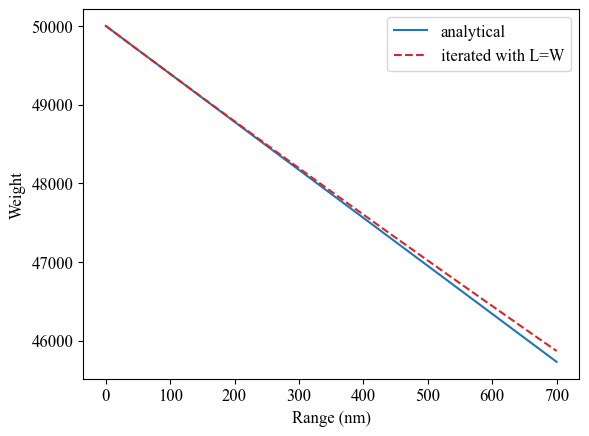

In [29]:
cruise_iterative(W_start=50000, R_nm=700)
W_start = 50000;
R = 700
plt.plot([0, R], [W_start, cruise_analytical(W_start=50000, M=0.85, R=700, alt=35000)])
plt.plot(np.linspace(0, 700, 30,), cruise_iterative(W_start, R, steps=30), color='tab:red', linestyle='--')
plt.legend(['analytical', 'iterated with L=W'])
plt.xlabel("Range (nm)")
plt.ylabel("Weight")

# cruise_analytical(W_start=50000, M=0.85, R=700,alt=35000)/W_start

In [58]:
def compute_climb(W_start, k = (1/(np.pi*p['e_oswald']*p['AR']))):
    g=32.2
    h_steps = np.linspace(0, p["h_cruise"], p["n_steps"] + 1)
    W = W_start
    dist_ft = 0.0
    for i in range(len(h_steps)-1):
        h1, h2 = h_steps[i], h_steps[i+1]
        rho1, _, sigma1, _ = isa_atmosphere(h1)
        rho2, _, sigma2, _ = isa_atmosphere(h2)
        
        # Velocities at start/end of step to calculate Delta Energy Height
        T1, T2 = p["T_sl_max"] * (sigma1**0.9), p["T_sl_max"] * (sigma2**0.9)
        V1 = np.sqrt(((W/p["Sref"])/(3*rho1*p["CD0"])) * ((T1/W) + np.sqrt(max((T1/W)**2 + 12*p["CD0"]*k, 0))))
        V2 = np.sqrt(((W/p["Sref"])/(3*rho2*p["CD0"])) * ((T2/W) + np.sqrt(max((T2/W)**2 + 12*p["CD0"]*k, 0))))
        
        # dhe = delta(h + V^2/2g)
        dhe = (h2 - h1) + (V2**2 - V1**2) / (2 * g)
        
        # Mid-point performance
        h_mid = (h1 + h2) / 2
        rho_m, _, sigma_m, theta_m = isa_atmosphere(h_mid)
        V_m = (V1 + V2) / 2
        CL = np.sqrt((p["CD0"]) / (3*k))
        CD = p["CD0"] + k * CL**2
        SFC = p["C_climb"]
        Ps = V_m * ((p["T_sl_max"] * sigma_m**0.9 / W) - (CD/CL)) 
        
        W *= np.exp(-((SFC/3600) * dhe) / Ps)
        dist_ft += (V_m / Ps) * dhe
    return W / W_start, dist_ft / 6076.12

In [59]:
def climb_iterative(W_start, g=32.2, S_ref=625, rho=rho, k = (1/(np.pi*p['e_oswald']*p['AR'])), C_D0=p['CD0']): 
    T = 29160 # lbf for now
    c_t = 0.9 / 3600
    steps = 12
    weight = [0] * steps
    x_climb = 0
    dh = 35000/steps

    weight[0] = W_start
    for i, w in enumerate(weight):
        if i >= len(weight)-1: break
        alt = i*dh
        V = np.sqrt((w / S_ref)/(3*rho(alt)*C_D0) * ((T/w) + np.sqrt((T/w)**2 + 12 * C_D0 * k)))
        D = 1/2 * rho(alt) * V**2 * S_ref * C_D0

        P_s = V*(T-D)/w
        dh_e = dh + V**2/(2*g)
        x = dh_e/P_s * V
        weight[i+1] = w * np.exp(-(c_t * dh_e)/(V*(1-D/T)))
        x_climb = x_climb + x
    distance_covered = x_climb /  6076.12 # convert from ft to nm
    return weight, distance_covered

In [54]:
wc, d = climb_iterative(W_start=50000)

In [55]:
wc[-1]/wc[0]

array([0.91309102])

In [60]:
compute_climb(W_start)

(np.float64(0.966360500497648), np.float64(27.226518203638438))

In [ ]:

def fuel_frac_refined(mission_list, MTOW_initial):
    k = 1.0 / (np.pi * p["AR"] * p["e_oswald"])
    
    # Starting Weight: Taxi & Takeoff
    ff_taxi = (1 - (15/60)*(p["C_taxi"]*(0.05 * p["T_sl_max"] / p["MTOW"])))
    W_exec = p["MTOW"] * ff_taxi
    ff_takeoff = 1 - (1.0 * (1/60) * (p["T_sl_max"] / W_exec))
    W_exec *= ff_takeoff
    
    x_climb_credit = 0.0

    def compute_climb(W_start):
        h_steps = np.linspace(0, p["h_cruise"], p["n_steps"] + 1)
        W = W_start
        dist_ft = 0.0
        for i in range(len(h_steps)-1):
            h_mid = (h_steps[i] + h_steps[i+1])/2
            dh = h_steps[i+1] - h_steps[i]
            rho, _, sigma, theta = isa_atmosphere(h_mid)
            T_max = p["T_sl_nom"] * (sigma**0.9) 
            TW = T_max / W
            V = np.sqrt(((W/p["Sref"])/(3*rho*p["CD0"])) * (TW + np.sqrt(max(TW**2 + 12*p["CD0"]*k, 0))))
            CL = np.sqrt((p["CD0"]) / (3*k))
            CD = p["CD0"] + k*CL**2
            SFC = p["C_climb"] * np.sqrt(theta)
            Ps = V * (TW - (CD/CL*W)) 
            W *= np.exp(-(SFC/3600) * dh / Ps)
            dist_ft += (V / Ps) * dh
        return W / W_start, dist_ft / 6076.12

    def compute_cruise_analytical(W_start, R_nm, x_credit):
        R_actual = max(R_nm - x_credit, 0) * 6076.12
        dR = R_actual / p["n_steps"]
        V = p["M_cruise"] * p["a_cruise"]
        _, _, _, theta = isa_atmosphere(p["h_cruise"])
        SFC = (p["C_cruise"] * np.sqrt(theta)) / 3600 # Convert to per second
        
        # Optimal CL for Cruise 
        # Often fly at sqrt(CD0/3k) or simply L/D max
        CL_opt = np.sqrt(p["CD0"] / (3*k)) 
        CD_opt = p["CD0"] + k * (CL_opt**2)
        LD = CL_opt / CD_opt

        weight_moving = W_start
        for _ in range(p["n_steps"]):
        # Wi/Wf = exp(R * ct / (V * L/D))
            weight_moving *= np.exp(-(dR * (SFC/3600)) / (V * LD))


        return weight_moving / W_start

    def compute_loiter_iterative(W_start, E_min):
        dt = (E_min * 60) / p["n_steps"]
        V = p["M_loiter"] * p["a_loiter"]
        rho, _, _, theta = isa_atmosphere(p["h_loiter"])
        SFC = p["C_loiter"] * np.sqrt(theta)
        W = W_start
        for _ in range(p["n_steps"]):
            CL = np.sqrt(p["CD0"] / k)
            CD = p["CD0"] + k * CL**2
            LD = CL / (CD+k*CL**2)
            ff_loiter = np.exp(-(p["C_loiter"]/3600*p["E_loiter"]*60/10) / (LD))
            W *= ff_loiter
        return W / W_start 

    for m in mission_list:
        if m == 1: continue 
        elif m == 2: # Climb
            ratio, x_climb_credit = compute_climb(W_exec)
            W_exec *= ratio
        elif m == 3: # Cruise
            W_exec *= compute_cruise_analytical(W_exec, p["R_cruise"], x_climb_credit)
            x_climb_credit = 0.0 
        elif m == 4: # Descent
            W_exec *= 0.99 
        elif m == 5: # Dash
            V = p["M_dash"] * p["a_dash"]
            LD_dash = 0.7 * (p["K_LD"] * np.sqrt(p["AR"] / p["Swet_Sref"]))
            W_exec *= np.exp(-(p["R_dash"]*6076.12*(p["C_dash"]/3600))/(V * LD_dash))
        elif m == 6: # Combat
            LD_combat = 0.2 * (p["K_LD"] * np.sqrt(p["AR"] / p["Swet_Sref"]))
            W_exec *= np.exp(-(p["E_combat"]*60*(p["C_after"]/3600))/LD_combat)
        elif m == 7: # Loiter
            W_exec *= compute_loiter_iterative(W_exec, p["E_loiter"])
        elif m == 8: # Landing
            W_exec *= 0.995 

    return 1.06 * (1 - (W_exec / MTOW_initial))

# Final Calculation Table
print(f"{'Mission Profile':<25} | {'Fuel Fraction'}")
print("-" * 55)
for name, sequence in mission_sequence.items():
    res = fuel_frac_refined(sequence, p["MTOW"])
    print(f"{name:<25} | {res:.4f}")